# 01 — Data Exploration

**Content:** In this notebook I am going to look at the raw data provided by Kaggle: [Historical NBA Data and Player Box Scores](https://www.kaggle.com/datasets/eoinamoore/historical-nba-data-and-player-box-scores))

I am going to extract the most important content and features.

## 1. Packages 

In [58]:
#packages
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# plot style Latex <3
sys.path.insert(0, str(Path("..").resolve()))
from src.plot_style import apply
apply()

# Path to the raw Kaggle data (relative to notebooks/)
DATA_DIR = Path("..") / "data" / "raw"
#print("Data directory:", DATA_DIR.resolve())
print("Files found:", [f.name for f in DATA_DIR.iterdir()])

Files found: ['Games.csv', 'LeagueSchedule24_25.csv', 'LeagueSchedule25_26.csv', 'PlayByPlay.parquet', 'Players.csv', 'PlayerStatistics.csv', 'PlayerStatisticsExtended.csv', 'TeamHistories.csv', 'TeamStatistics.csv', 'TeamStatisticsExtended.csv']


## 2. Content in files:

Getting a general overview of the content each file holds. **ALLERT:** Do **NOT RUN** if not interested haha


In [59]:
for f in sorted(DATA_DIR.iterdir()):
    if f.suffix == ".csv":
        cols = pd.read_csv(f, nrows=0, low_memory=False).columns.tolist()
    elif f.suffix == ".parquet":
        cols = pq.read_schema(f).names
    else:
        continue
    print(f"{f.name}  ({len(cols)} columns)")
    print(f"   {cols}")
    print()

Games.csv  (23 columns)
   ['gameId', 'gameDateTimeEst', 'hometeamCity', 'hometeamName', 'hometeamId', 'awayteamCity', 'awayteamName', 'awayteamId', 'homeScore', 'awayScore', 'winner', 'gameType', 'gameSubtype', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'attendance', 'arenaId', 'arenaName', 'arenaCity', 'arenaState', 'officials', 'gameDate']

LeagueSchedule24_25.csv  (15 columns)
   ['gameId', 'gameDateTimeEst', 'gameDay', 'arenaCity', 'arenaState', 'arenaName', 'gameLabel', 'gameSubLabel', 'gameSubtype', 'gameSequence', 'seriesGameNumber', 'seriesText', 'weekNumber', 'hometeamId', 'awayteamId']

LeagueSchedule25_26.csv  (17 columns)
   ['gameId', 'gameDateTimeEst', 'gameDay', 'homeTeamId', 'awayTeamId', 'homeTeamName', 'homeTeamCity', 'awayTeamName', 'awayTeamCity', 'arenaName', 'arenaCity', 'arenaState', 'gameLabel', 'gameSubLabel', 'gameSubtype', 'seriesGameNumber', 'weekNumber']

PlayByPlay.parquet  (89 columns)
   ['clock', 'actionType', 'description', 'playerFullName', 'te

`PlayerStatisticsExtended.csv` (110 columns) — just missing social security number ;)

In [74]:
# Looking at top players
ps = pd.read_csv(DATA_DIR / "PlayerStatistics.csv", parse_dates=["gameDate"], low_memory=False)
print(f"Loaded: {len(ps):,} player-game rows")

# drop rows with missing player/team info
ps = ps.dropna(subset=["firstName", "lastName", "playerteamName"]).copy()
print(f"After excluding NaN rows: {len(ps):,}")

cols = ["firstName", "lastName", "playerteamName", "gameDate"]

print("\nMost points in a single game:")
print(ps.nlargest(3, "points")[cols + ["points"]])

print("\nMost blocks in a single game:")
print(ps.nlargest(3, "blocks")[cols + ["blocks"]])



Loaded: 1,668,357 player-game rows
After excluding NaN rows: 1,664,829

Most points in a single game:
        firstName     lastName playerteamName            gameDate  points
1593306      Wilt  Chamberlain       Warriors 1962-03-02 19:00:00   100.0
8035          Bam      Adebayo           Heat 2026-03-10 19:30:00    83.0
721169       Kobe       Bryant         Lakers 2006-01-22 21:30:00    81.0

Most blocks in a single game:
         firstName lastName playerteamName            gameDate  blocks
1477479     Elmore    Smith         Lakers 1973-10-28 19:00:00    17.0
1073333  Shaquille   O'Neal          Magic 1993-11-20 20:00:00    15.0
1221936     Manute      Bol        Bullets 1987-02-26 20:00:00    15.0


## 3. Loading `Games.csv`

This is my main dataset: one row per NBA game, with home/away teams, scores, and the winner.

In [60]:
games = pd.read_csv(DATA_DIR / "Games.csv", parse_dates=["gameDate"], low_memory=False)
print(f"Number of games: {len(games):,}")
print(f"columns: {games.shape[1]}")
print(f"Date range: {games.gameDate.min().date()}  till  {games.gameDate.max().date()}")
games.head()

Number of games: 73,224
columns: 23
Date range: 1946-11-26  till  2026-04-26


,gameId,gameDateTimeEst,hometeamCity,hometeamName,hometeamId,awayteamCity,awayteamName,awayteamId,homeScore,awayScore,...,gameLabel,gameSubLabel,seriesGameNumber,attendance,arenaId,arenaName,arenaCity,arenaState,officials,gameDate
0,42500174,2026-04-26 21:30:00,Houston,Rockets,1610612745,Los Angeles,Lakers,1610612747,115,96,...,West First Round,Game 4,Game 4,18055.0,215,Toyota Center,Houston,TX,"JB DeRosa, Kevin Scott, James Williams, Nate G...",2026-04-26 21:30:00
1,42500114,2026-04-26 19:00:00,Philadelphia,76ers,1610612755,Boston,Celtics,1610612738,96,128,...,East First Round,Game 4,Game 4,19746.0,1000152,Xfinity Mobile Arena,Philadelphia,PA,"Ed Malloy, Mark Lindsay, Josh Tiven, Mousa Dagher",2026-04-26 19:00:00
2,42500154,2026-04-26 15:30:00,Portland,Trail Blazers,1610612757,San Antonio,Spurs,1610612759,93,114,...,West First Round,Game 4,Game 4,19717.0,51,Moda Center,Portland,OR,"Zach Zarba, Dedric Taylor, Justin Van Duyne, A...",2026-04-26 15:30:00
3,42500134,2026-04-26 13:00:00,Toronto,Raptors,1610612761,Cleveland,Cavaliers,1610612739,93,89,...,East First Round,Game 4,Game 4,19800.0,643,Scotiabank Arena,Toronto,ON,"John Goble, Curtis Blair, Ray Acosta, Natalie ...",2026-04-26 13:00:00
4,42500164,2026-04-25 20:30:00,Minnesota,Timberwolves,1610612750,Denver,Nuggets,1610612743,112,96,...,West First Round,Game 4,Game 4,18978.0,61,Target Center,Minneapolis,MN,"Marc Davis, Pat Fraher, Sean Wright, Jason Gol...",2026-04-25 20:30:00


In [61]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 73224 entries, 0 to 73223
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   gameId            73224 non-null  int64         
 1   gameDateTimeEst   73224 non-null  str           
 2   hometeamCity      73217 non-null  str           
 3   hometeamName      73224 non-null  str           
 4   hometeamId        73224 non-null  int64         
 5   awayteamCity      73217 non-null  str           
 6   awayteamName      73224 non-null  str           
 7   awayteamId        73224 non-null  int64         
 8   homeScore         73224 non-null  int64         
 9   awayScore         73224 non-null  int64         
 10  winner            73224 non-null  int64         
 11  gameType          73224 non-null  str           
 12  gameSubtype       74 non-null     str           
 13  gameLabel         3988 non-null   str           
 14  gameSubLabel      273 non-null   

## 4. Checking for missing values:

In [62]:
missing = games.isnull().sum().sort_values(ascending=False) # here I check the number of empty cellc per column
missing_pct = (missing / len(games) * 100).round(2) #pct = % 
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct}) # table
missing_df[missing_df.missing > 0] # only show columns with missing entries

,missing,pct
gameSubtype,73150,99.90
gameSubLabel,72951,99.63
arenaState,71888,98.18
attendance,71887,98.17
officials,71879,98.16
arenaCity,71879,98.16
arenaName,71879,98.16
gameLabel,69236,94.55
seriesGameNumber,67456,92.12
hometeamCity,7,0.01


In [66]:

worst_col = missing_df[missing_df.missing > 0].index[0]
games[games[worst_col].isnull()].gameDate.dt.year.value_counts().sort_index().head(10)

gameDate
1946      7
1947     25
1948     47
1949     97
1950    166
1951    230
1952    228
1953    252
1954    278
1955    306
Name: count, dtype: int64

## 5. Games per season 

Currently 30 teams x 82 games / 2. Expecting ~1200 games per season

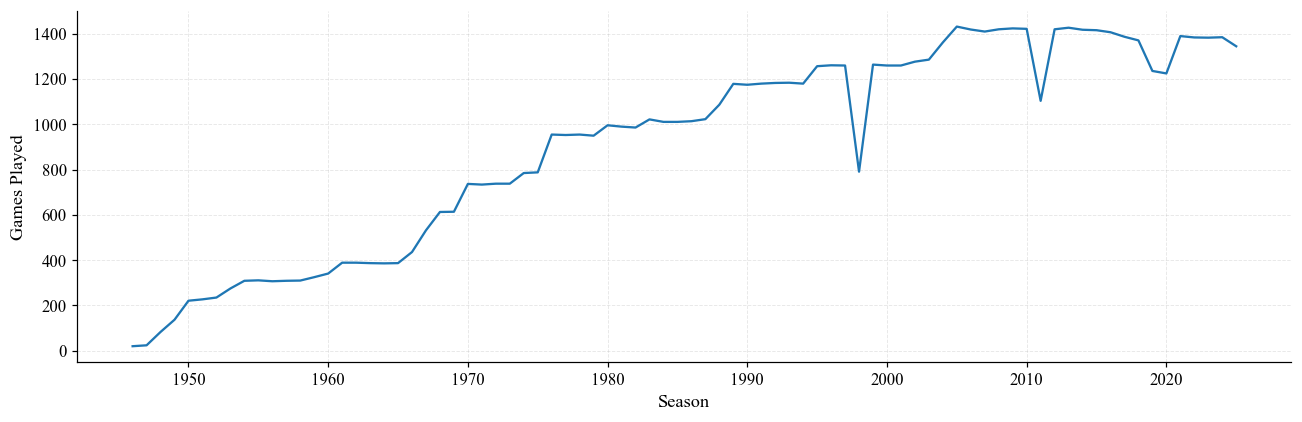

First season:  1946  (20 games)
Current season: 2025  (1345 games)


In [63]:
# Season goes from Oct till June: Convention is that a game in Feburary 2024 is still part of season 2023... just making sure here

games["season"] = np.where(
    games.gameDate.dt.month >= 10,
    games.gameDate.dt.year,
    games.gameDate.dt.year - 1
)

games_per_season = games.groupby("season").size()

#plot
fig, ax = plt.subplots(figsize=(12, 4))
games_per_season.plot(ax=ax, color="#1f77b4")
ax.set_xlabel("Season")
ax.set_ylabel("Games Played")
plt.tight_layout()
plt.show()

print(f"First season:  {games_per_season.index.min()}  ({games_per_season.iloc[0]} games)")
print(f"Current season: {games_per_season.index.max()}  ({games_per_season.iloc[-1]} games)")

### NBA Lockout:

In case you are wondering as me, here are the reasons for the dips. I guess Covid is selfexplaining:

*   **[2011 NBA Lockout](https://en.wikipedia.org/wiki/2011_NBA_lockout)**
*   **[1998–99 NBA Lockout](https://en.wikipedia.org/wiki/1998%E2%80%9399_NBA_lockout)**

## 6. Home Advantage?


In [53]:
played = games.dropna(subset=["homeScore", "awayScore"]).copy() # Excluding all games with missing scores
played["home_win"] = played.homeScore > played.awayScore
#print(played["home_win"])
home_win_rate = played.home_win.mean() # home win rate
print(f"Home-Win-Rate all seasons: {home_win_rate:.1%}")
print(f"Number of analysed games: {len(played):,}")

Home-Win-Rate all seasons: 61.6%
Number of analysed games: 73,224


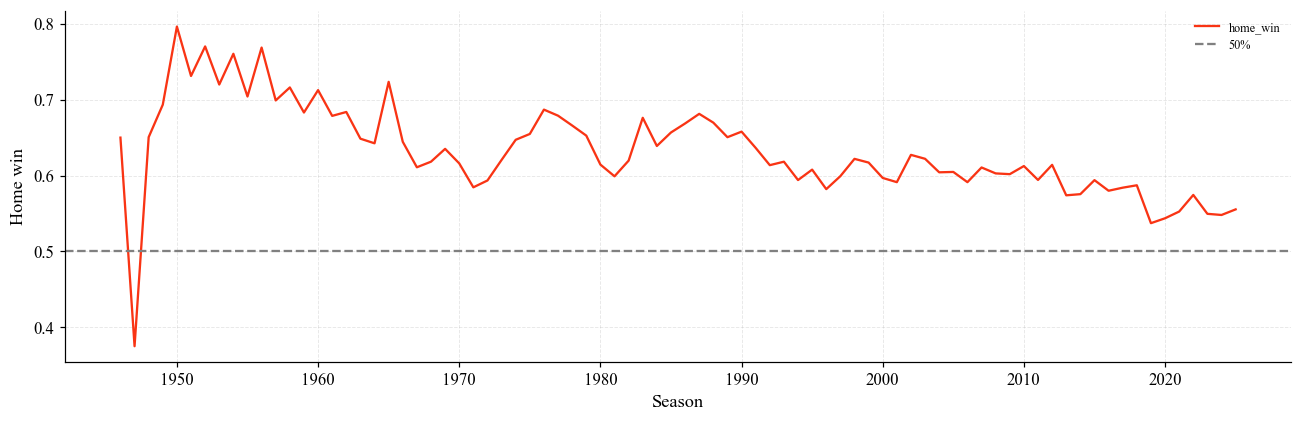

In [54]:
# Home win rate per season
home_win_by_season = played.groupby("season").home_win.mean()

fig, ax = plt.subplots(figsize=(12, 4))
home_win_by_season.plot(ax=ax, color="#f93414")
ax.axhline(0.5, color="gray", linestyle="--", label="50%")
ax.set_xlabel("Season")
ax.set_ylabel("Home win")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Score Distribution

What does a typical final score look like? Has the scoring level changed over the decades?

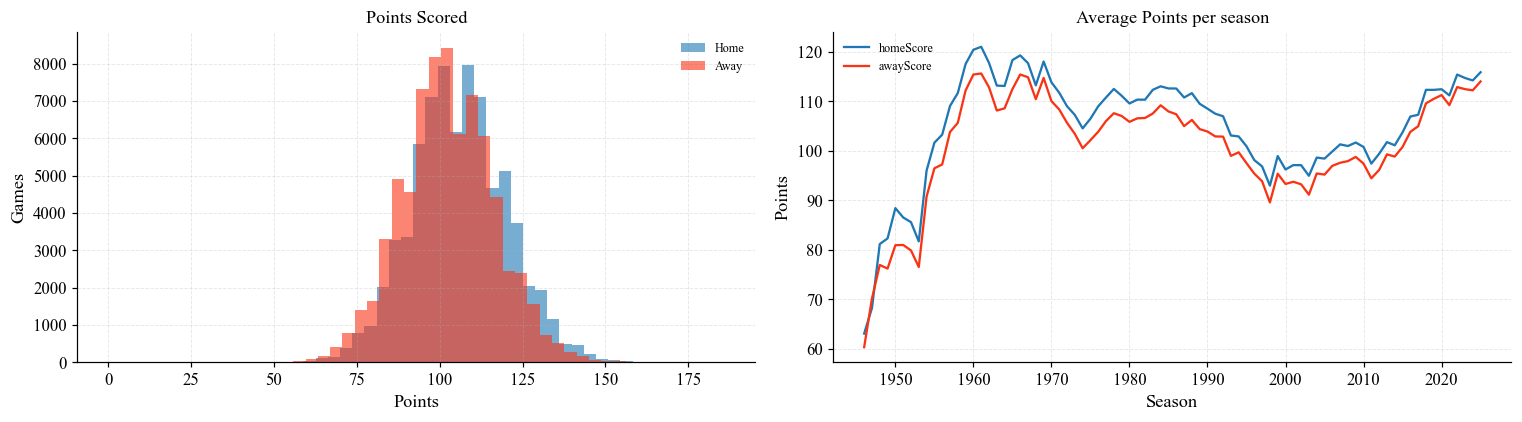

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Score distribution
axes[0].hist(played.homeScore, bins=50, alpha=0.6, label="Home", color="#1f77b4")
axes[0].hist(played.awayScore, bins=50, alpha=0.6, label="Away", color="#f93414")
axes[0].set_title("Points Scored")
axes[0].set_xlabel("Points")
axes[0].set_ylabel("Games")
axes[0].legend()

# Avg score per season
avg_score = played.groupby("season")[["homeScore", "awayScore"]].mean()
avg_score.plot(ax=axes[1])
axes[1].set_title("Average Points per season")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Points")

plt.tight_layout()
plt.show()

## 8. Game Types

Regular Season vs. Playoffs  

In [46]:
games.gameType.value_counts()

gameType
Regular Season        66768
Playoffs               4471
Preseason              1873
NBA Emirates Cup         66
Play-in Tournament       37
All-Star Game             7
Emirates NBA Cup          1
NBA Cup                   1
Name: count, dtype: int64

In [71]:
# home win rates in during different types of competiotion
played["gameType"] = games.loc[played.index, "gameType"]
played.groupby("gameType").home_win.mean()

gameType
All-Star Game         0.571429
Emirates NBA Cup      1.000000
NBA Cup               1.000000
NBA Emirates Cup      0.590909
Play-in Tournament    0.675676
Playoffs              0.644375
Preseason             0.565403
Regular Season        0.615280
Name: home_win, dtype: float64

**Interesting:** There is a ~ 3% difference in Playoffs (0.64) vs. Regular Season (0.61)